# Welp Businesses: An Analytical Review of Yelp Businesses and Urban Travel
### Team Members
**Owen Widdis** - owidd | MSI Big Data Analytics | Geospatial and Environmental Focus

**Moe Khashafa** - khashafa | MSI Big Data Analytics | Digital Media Focus

**Kyle Lee** - kylejlee | MSI Big Data Analytics | Quantitative Finance Focus

### Overview
Our team is focusing on two datasets: US Cities Urban Connectivity and Yelp Business datasets. We are researching the relationship between urban travel and business distributions across different US cities.

### Motivation
We’re interested in determining whether the way a city is built affects what kind of businesses actually do well there. Walkability is a big thing in urban planning right now, but we want to find out if it actually has an impact on what businesses show up in different areas. This could be useful for city planners or people looking to start a business. 

In [1]:
# Setup and Imports
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import tukey_hsd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


/Users/kylelee/Desktop/si618/SI_618_Class/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load datasets
urban_path = kagglehub.dataset_download("vellis1/us-cities-urban-connectivity")
yelp_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")

# Load urban connectivity data
files = os.listdir(urban_path)
csv_files = [f for f in files if f.endswith('.csv')]
urban_df = pd.read_csv(os.path.join(urban_path, csv_files[0]))

# Load Yelp business data
yelp_business_path = os.path.join(yelp_path, "yelp_academic_dataset_business.json")
yelp_df = pd.read_json(yelp_business_path, lines=True)

print(f"Urban data shape: {urban_df.shape}")
print(f"Yelp data shape: {yelp_df.shape}")

Urban data shape: (102, 79)
Yelp data shape: (150346, 14)


In [3]:
# Category mapping rules - comprehensive keyword matching
MAJOR_RULES = {
    "Food & Dining": [
        "restaurant","food","cafe","coffee","tea","bar","bakery","dessert","ice cream",
        "pizza","burger","sandwich","noodle","ramen","sushi","mexican","italian","korean",
        "thai","indian","chinese","japanese","mediterranean","halal","vegan","vegetarian",
        "brunch","breakfast","deli","seafood","steakhouse","bbq","brew","wine","pub",
        "grocery","market","butcher","donut","bagel","taco","poke","buffet","food truck",
        "american (traditional)","american (new)","salad","chicken wings","cajun","creole",
        "southern","diners","latin american","soup","vietnamese","asian fusion",
        "middle eastern","gluten-free","tex-mex","greek","french","cuban","fish & chips",
        "dim sum","creperies","hawaiian","falafel","african","puerto rican","turkish",
        "german","cantonese","hot pot","filipino","brazilian","ethiopian","kosher",
        "pakistani","irish","szechuan","lebanese","kebab","brasseries","pan asian",
        "empanadas","persian","iranian","teppanyaki","malaysian","fondue","izakaya",
        "shanghainese","mongolian","himalayan","nepalese","ukrainian","egyptian",
        "singaporean","burmese","armenian","syrian","scandinavian","australian",
        "bangladeshi","sicilian","senegalese","haitian","trinidadian","iberian",
        "hungarian","somali","sardinian","georgian","sri lankan","guamanian",
        "serbo croatian","czech","hainan","israeli","fuzhou","south african",
        "colombian","peruvian","venezuelan","salvadoran","dominican","russian",
        "honduran","laotian","argentine","belgian","portuguese","british","moroccan",
        "afghan","arabic","polish","cambodian","indonesian","basque","taiwanese",
        "smokehouse","pretzels","waffles","shaved ice","acai bowls","gelato",
        "custom cakes","cupcakes","fruits & veggies","wraps","kombucha",
        "herbs & spices","olive oil","honey","pancakes","beer hall","poutineries",
        "bistros","street vendors","personal chefs","distilleries","cideries",
        "meaderies","speakeasies","beer","cucina campana","tuscan","austrian", "bakeries"
    ],
    "Shopping & Retail": [
        "store","shop","shopping","fashion","clothing","jewelry","gift","book","electronics",
        "furniture","thrift","antique","cosmetic","supply","wholesale","mall","marketplace",
        "shoe","accessories","toy","department","boutique",
        "home decor","sporting goods","mags","used","vintage & consignment",
        "mobile phones","building supplies","kitchen & bath","eyewear & opticians",
        "mattresses","watches","lighting fixtures","outdoor gear","guns & ammo",
        "leather goods","vinyl records","lingerie","costumes","formal wear",
        "motorcycle gear","hats","perfume","luggage","swimwear","knitting supplies",
        "customized merchandise","wigs","religious items","uniforms","kitchen supplies",
        "office equipment","rugs","shades & blinds","tableware","military surplus",
        "hunting & fishing supplies","gemstones & minerals","gold buyers",
        "diamond buyers","firewood","safety equipment","vitamins & supplements",
        "computers","signmaking","framing","grilling equipment"
    ],
    "Beauty & Personal Care": [
        "salon","spa","hair","nail","wax","tattoo","piercing","massage","skin","makeup",
        "barber","tanning","eyelash","threading","facial",
        "blow dry/out services","eyebrow services","sugaring","acne treatment",
        "aestheticians","estheticians"
    ],
    "Health & Medical": [
        "doctor","dentist","hospital","medical","clinic","therapy","chiropractor",
        "optometrist","psychologist","psychiatrist","surgeon","pharmacy","rehab",
        "urgent care","health","wellness","nutrition",
        "orthodontists","endodontists","periodontists","family practice",
        "acupuncture","reflexology","weight loss centers","diagnostic services",
        "dermatologists","ophthalmologists","internal medicine","obstetricians",
        "gynecologists","pediatricians","orthopedists","naturopathic","holistic",
        "reiki","laboratory testing","pain management","laser eye surgery","lasik",
        "allergists","gastroenterologist","neurologist","podiatrists","ear nose & throat",
        "radiologists","urologists","fertility","endocrinologists","oncologist",
        "sleep specialists","osteopathic physicians","audiologist","prosthodontists",
        "nurse practitioner","addiction medicine","dental hygienists","dietitians",
        "hearing aid providers","pulmonologist","speech therapists","vascular medicine",
        "emergency rooms","emergency medicine","iv hydration","colonics",
        "alternative medicine","meditation centers","tui na","tai chi","qi gong",
        "ayurveda","preventive medicine","concierge medicine","lactation services",
        "midwives","hospice","skilled nursing","assisted living facilities",
        "diagnostic imaging","teeth whitening","orthotics"
    ],
    "Automotive": [
        "auto","car","vehicle","tire","oil change","repair","dealer","towing","smog",
        "body shop","transmission","glass","detailing",
        "gas stations","roadside assistance","ev charging stations"
    ],
    "Home & Local Services": [
        "plumbing","electrician","hvac","roof","contractor","cleaning","locksmith",
        "moving","landscaping","flooring","installation","repair","maintenance","handyman",
        "appliance","home service","garden",
        "local services","movers","sewing & alterations","printing services",
        "shipping centers","pest control","painters","tree services",
        "junk removal & hauling","damage restoration","masonry/concrete",
        "packing services","pool & hot tub service","irrigation","window washing",
        "landscape architects","pool cleaners","gutter services","pressure washers",
        "garage door services","fences & gates","home window tinting","cabinetry",
        "tiling","laundry services","laundromat","refinishing services",
        "grout services","demolition services","stucco services","snow removal",
        "siding","decks & railing","chimney sweeps","fireplace services",
        "hydro-jetting","septic services","tv mounting","shutters","patio coverings",
        "home inspectors","home organization","home staging","awnings",
        "fire protection services","environmental abatement","screen printing",
        "interior design","florists","floral designers","swimming pools",
        "hot tub & pool","home energy auditors","well drilling","excavation services",
        "backflow services","wallpapering","powder coating","grill services",
        "wildlife control","home developers","interlock systems",
        "sheds & outdoor storage","security systems","security services",
        "environmental testing"
    ],
    "Real Estate & Housing": [
        "real estate","apartment","property","mortgage","housing","leasing",
        "condominiums","self storage","homeowner association"
    ],
    "Professional & Financial Services": [
        "law","legal","account","insurance","tax","consult","financial","bank",
        "notary","payday","broker","business service",
        "professional services","general litigation","investing",
        "check cashing/pay-day loans","title loans","installment loans",
        "debt relief services","payroll services","employment agencies",
        "advertising","graphic design","web design","appraisal services",
        "registration services","personal assistants","wills","trusts","& probates",
        "business financing","process servers","editorial services",
        "translation services","software development","billing services",
        "data recovery","internet service providers","utilities",
        "electricity suppliers","talent agencies","structural engineers"
    ],
    "Entertainment & Recreation": [
        "gym","fitness","park","museum","art","music","theater","cinema","club",
        "karaoke","festival","sports","golf","yoga","dance","arcade","game",
        "recreation","bowling","casino",
        "nightlife","active life","event planning & services","lounges",
        "trainers","boot camps","pilates","jazz & blues","kids activities",
        "pool halls","boxing","stadiums & arenas","skating rinks","hiking",
        "boating","kickboxing","tennis","mountain biking","climbing",
        "brazilian jiu-jitsu","horseback riding","fishing","gun/rifle ranges",
        "rafting/kayaking","axe throwing","paint & sip","challenge courses",
        "diving","scuba diving","rock climbing","laser tag","paintball",
        "virtual reality centers","archery","skydiving","surfing","tubing",
        "hot air balloons","batting cages","sailing","free diving",
        "adult entertainment","adult","haunted houses","scavenger hunts",
        "jet skis","soccer","basketball courts","baseball fields","marinas",
        "opera & ballet","playgrounds","summer camps","day camps",
        "indoor playcentre","aquariums","zoos","landmarks & historical buildings",
        "local flavor","libraries","beaches","lakes","campgrounds",
        "horse racing","race tracks","djs","pool & billiards","eatertainment",
        "pumpkin patches","attraction farms","bike sharing","bicycle paths",
        "pickleball","bocce ball","badminton","skiing","sledding",
        "outdoor movies","bingo halls","rodeo","airsoft","cannabis dispensaries",
        "cannabis collective","bikes","swimming pools","snowboarding",
        "hang gliding","ziplining","snorkeling","trivia hosts",
        "recording & rehearsal studios","video/film production","magicians",
        "face painting","clowns","wildlife hunting ranges","metal detector services"
    ],
    "Education": [
        "school","college","university","tutor","training","education","class","lesson",
        "test preparation"
    ],
    "Travel & Transportation": [
        "hotel","travel","tour","airport","taxi","transport","rental","shuttle",
        "airline","resort","vacation",
        "limos","guest houses","hostels","train stations","buses","bus stations",
        "ferries","pedicabs","valet services","luggage storage","rest stops",
        "visitor centers","trains","flight instruction"
    ],
    "Pets": [
        "pet","veterinarian","animal","dog","cat","groomer","boarding",
        "aquarium services"
    ],
    "Community & Public Services": [
        "community service/non-profit","religious organizations","churches",
        "cultural center","community centers","funeral services & cemeteries",
        "cremation services","mortuary services","post offices","courthouses",
        "donation center","recycling center","blood & plasma donation centers",
        "synagogues","buddhist temples","hindu temples","mosques",
        "homeless shelters","jails & prisons","municipality","embassy",
        "crisis pregnancy centers","faith-based crisis pregnancy centers",
        "adoption services","hospice"
    ],
    "Events & Weddings": [
        "wedding planning","bridal","photographers","session photography",
        "event photography","boudoir photography","videographers",
        "wedding chapels","officiants","balloon services","holiday decorations",
        "holiday decorating services","christmas trees","paint-your-own pottery",
        "screen printing/t-shirt printing","engraving","calligraphy",
        "digitizing services","customized merchandise"
    ]
}

def map_major_category(category):
    if pd.isna(category):
        return "Other"
    c = category.lower()
    for major, keywords in MAJOR_RULES.items():
        for k in keywords:
            if k in c:
                return major
    return "Other"

In [4]:
# Data Cleaning and Merging
urban_df = urban_df.rename(columns={"State": "state", "City": "city"})

# Merge on both city and state for accurate geographic matching
combined = pd.merge(left=urban_df, right=yelp_df, 
                    left_on=["city", "state"], 
                    right_on=["city", "state"], 
                    how="inner")

# Process categories
combined['categories'] = combined['categories'].str.split(", ")
combined = combined.explode('categories')
combined["major_category"] = combined["categories"].apply(map_major_category)

# Create Travel Score (avg of all scores)
combined['Travel_Score'] = (combined['Walk Score'] + combined['Transit Score'] + combined['Bike Score']) / 3

# Filter to open businesses only
combined = combined[combined['is_open'] == 1]

# Keep relevant columns
keep_cols = ['Place_name', 'city', 'state', 'Walk Score', 'Transit Score', 'Bike Score',
            'business_id', 'name', 'postal_code', 'latitude', 'longitude', 
            'stars', 'review_count', 'major_category', 'Travel_Score']
combined = combined[[col for col in keep_cols if col in combined.columns]]

# Deduplicate by business_id
combined_deduped = combined.drop_duplicates(subset=['business_id'])

print(f"Combined dataset shape: {combined.shape}")
print(f"Unique businesses: {combined_deduped.shape[0]}")
print(f"Unique cities: {combined_deduped['city'].nunique()}")

Combined dataset shape: (191058, 15)
Unique businesses: 42074
Unique cities: 14


In [5]:
# Create multi-hot encoded dataset for multivariate analysis
combined_onehot = pd.get_dummies(combined[['business_id', 'major_category']], 
                                columns=['major_category'], dtype=int)

# Group by business_id to create multi-hot encoding
category_cols = [col for col in combined_onehot.columns if col.startswith('major_category_')]
business_categories = combined_onehot.groupby('business_id')[category_cols].max().reset_index()

# Merge back with business data
combined_final = combined_deduped.drop(columns=['major_category']).merge(business_categories, on='business_id')
combined_final = combined_final.dropna()

print(f"Final dataset shape: {combined_final.shape}")

Final dataset shape: (42074, 29)


---
# 1. Inferential Statistics

In this section, we conducted hypothesis tests to investigate significant differences and correlations within the data
- **Regression Analysis**: Testing if mobility scores predict business engagement
- **ANOVA**: Testing if Travel Score differs across business categories
- **Chi-Square Test**: Testing if business type distribution differs by transit accessibility

## Regression Analysis: Mobility Scores Predicting Business Engagement

**Main Question:** Do Walk Score, Transit Score, and Bike Score predict business engagement (review count)?

**Hypotheses:**
- H0 (Null): Mobility scores do not predict review count (all coefficients = 0)
- H1 (Alternative): At least one mobility score predicts review count

**Significance Level:** alpha = 0.05

We began by running simple and multiple linear regression to test whether Travel Score and the components that make it up, could predict a business's star rating or review count. Both models returned extremely low R² values and the multiple regression on log-transformed review count only explained about 0.27% of variance in training and 0.35% on the test set, with coefficients close to zero on all tests. This told us that mobility scores alone aren't strong predictors of individual business performance. We also plotted the relationships as scatter plots with the thought of Anscombe's Quartet, which we recently discussed in SI 568, where visualization can reveal structure that summary statistics miss, but the scatter plots confirmed what the regression already showed. We attributed the weak signal partly to the data lost in the merge, since we were left with only 14 cities instead of the full urban connectivity dataset. Given this, we pivoted to approaches better suited to the nature of our data.


In [6]:
# Prepare data for regression
combined_final['log_review_count'] = np.log1p(combined_final['review_count'])

X = combined_final[['Walk Score', 'Transit Score', 'Bike Score']]
y = combined_final['log_review_count']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Results
print("="*60)
print("MULTIPLE LINEAR REGRESSION RESULTS")
print("="*60)
print(f"\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.6f}")
print(f"  Intercept: {model.intercept_:.6f}")

train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f"\nModel Fit:")
print(f"  R-squared (Training): {train_r2:.4f}")
print(f"  R-squared (Test): {test_r2:.4f}")

MULTIPLE LINEAR REGRESSION RESULTS

Coefficients:
  Walk Score: 0.005723
  Transit Score: -0.000004
  Bike Score: -0.005279
  Intercept: 3.203796

Model Fit:
  R-squared (Training): 0.0027
  R-squared (Test): 0.0035


## One-Way ANOVA: Travel Score Across Business Categories

**Main Question:** Does the average Travel Score differ significantly across business categories?

**Hypotheses:**
- H0 (Null): All business category means for Travel Score are equal
- H1 (Alternative): At least one category mean differs from the others

**Significance Level:** alpha = 0.05

We ran a one-way ANOVA to test whether average Travel Score differed significantly across our 15 business categories. The result was highly significant (F = 61.53, p = 2.06e-174), so we rejected the null hypothesis that all category means are equal. A Post-hoc Tukey's HSD identified 38 significant pairwise differences, with the most notable being that Food & Dining businesses tend to cluster in higher-transit areas while Automotive businesses skew toward lower-transit ones with a gap of about 2.73 points in mean Travel Score between those two categories.

In [7]:
# Prepare data for ANOVA
category_groups = [group['Travel_Score'].values 
                   for name, group in combined.groupby('major_category')]
category_names = list(combined.groupby('major_category').groups.keys())

# Descriptive statistics by category
travel_by_category = combined.groupby('major_category')['Travel_Score'].agg(['mean', 'std', 'count'])
travel_by_category = travel_by_category.sort_values('mean', ascending=False)
print("Descriptive Statistics: Travel Score by Business Category")
print(travel_by_category.round(2))

Descriptive Statistics: Travel Score by Business Category
                                    mean    std  count
major_category                                        
Food & Dining                      51.10  14.34  63015
Community & Public Services        50.76  13.37    782
Education                          50.01  13.57   2011
Other                              49.95  13.46   1234
Entertainment & Recreation         49.93  13.93  21640
Beauty & Personal Care             49.88  13.61  15030
Professional & Financial Services  49.53  13.21   4292
Events & Weddings                  49.46  14.38    943
Shopping & Retail                  49.37  13.54  24093
Pets                               49.34  13.40   4312
Home & Local Services              49.31  13.12  19736
Real Estate & Housing              48.90  13.65   3954
Health & Medical                   48.90  12.82  12956
Travel & Transportation            48.53  13.34   5295
Automotive                         48.37  12.68  11765


In [8]:
# One-Way ANOVA
f_stat, anova_p = stats.f_oneway(*category_groups)

print("="*60)
print("ONE-WAY ANOVA RESULTS")
print("="*60)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p:.2e}")
print(f"\nSignificance level: alpha = 0.05")
print(f"\nConclusion: {'REJECT H0' if anova_p < 0.05 else 'FAIL TO REJECT H0'}")
if anova_p < 0.05:
    print("There is a statistically significant difference between Travel Score in business categories.")

ONE-WAY ANOVA RESULTS
F-statistic: 61.5279
P-value: 2.06e-174

Significance level: alpha = 0.05

Conclusion: REJECT H0
There is a statistically significant difference between Travel Score in business categories.


In [9]:
# Tukey's HSD
tukey_result = tukey_hsd(*category_groups)

significant_pairs = []
for i in range(len(category_names)):
    for j in range(i+1, len(category_names)):
        p_val = tukey_result.pvalue[i, j]
        if p_val < 0.05:
            mean_i = travel_by_category.loc[category_names[i], 'mean']
            mean_j = travel_by_category.loc[category_names[j], 'mean']
            significant_pairs.append({
                'Category 1': category_names[i],
                'Category 2': category_names[j],
                'Mean Difference': mean_i - mean_j,
                'p-value': p_val
            })

sig_df = pd.DataFrame(significant_pairs).sort_values('p-value')
print("="*60)
print(f"Tukey's HSD")
print(f"Significant pairwise differences (p < 0.05): {len(sig_df)} pairs")
print("="*60)
print(sig_df.head(15))

Tukey's HSD
Significant pairwise differences (p < 0.05): 38 pairs
                    Category 1                         Category 2  \
21  Entertainment & Recreation                      Food & Dining   
3                   Automotive         Entertainment & Recreation   
4                   Automotive                      Food & Dining   
28               Food & Dining                   Health & Medical   
34               Food & Dining            Travel & Transportation   
33               Food & Dining                  Shopping & Retail   
29               Food & Dining              Home & Local Services   
10      Beauty & Personal Care                      Food & Dining   
32               Food & Dining              Real Estate & Housing   
0                   Automotive             Beauty & Personal Care   
30               Food & Dining                               Pets   
31               Food & Dining  Professional & Financial Services   
22  Entertainment & Recreation       

## Chi-Square Test: Business Type Distribution by Transit Accessibility

**Main Question:** Is the distribution of business types different between high and low Travel Score areas?

**Hypotheses:**
- H0 (Null): Business type distribution is independent of Travel Score level
- H1 (Alternative): Business type distribution depends on Travel Score level

**Significance Level:** alpha = 0.05

We split the dataset at the median Travel Score into high- and low-transit groups and ran a chi-square test of independence to see whether the distribution of business categories differed between them. The test was significant (χ² = 526.01, df = 14, p = 2.83e-103), so we rejected the null that business type is independent of transit level. Cramér's V came out to 0.0525 which indicated a small effect. While the difference is real and statistically detectable at this sample size, the actual shift in business composition between high- and low-transit areas is marginal. Food & Dining and Entertainment are proportionally more common in high-transit areas, Automotive in low-transit, but transit accessibility alone isn't dramatically reshaping what kinds of businesses exist where.

In [10]:
combined = combined.reset_index(drop=True)

# Difference between "high" and "low" travel score based on median
median_travel = combined['Travel_Score'].median()
combined['travel_group'] = combined['Travel_Score'].apply(
    lambda x: 'High Transit' if x >= median_travel else 'Low Transit'
)

# Create contingency table
contingency = pd.crosstab(combined['major_category'], combined['travel_group'])

print("Contingency Table: Business Counts by Category and Travel Score Group")
print(contingency)

Contingency Table: Business Counts by Category and Travel Score Group
travel_group                       High Transit  Low Transit
major_category                                              
Automotive                                 6169         5596
Beauty & Personal Care                     7927         7103
Community & Public Services                 478          304
Education                                  1124          887
Entertainment & Recreation                12232         9408
Events & Weddings                           484          459
Food & Dining                             36805        26210
Health & Medical                           6612         6344
Home & Local Services                     10913         8823
Other                                       685          549
Pets                                       2390         1922
Professional & Financial Services          2191         2101
Real Estate & Housing                      1979         1975
Shopping & Reta

In [11]:
# Chi-Square Test
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)

print("="*60)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*60)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {chi2_p:.2e}")
print(f"\nSignificance level: alpha = 0.05")
print(f"\nConclusion: {'REJECT H0' if chi2_p < 0.05 else 'FAIL TO REJECT H0'}")
if chi2_p < 0.05:
    print("Business type distribution is significantly different between high and low transit areas.")

# Cramer's V
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"\nEffect Size (Cramer's V): {cramers_v:.4f}")
print(f"Interpretation: {'Small' if cramers_v < 0.1 else ('Medium' if cramers_v < 0.3 else 'Large')} effect")

CHI-SQUARE TEST OF INDEPENDENCE
Chi-square statistic: 526.0055
Degrees of freedom: 14
P-value: 2.83e-103

Significance level: alpha = 0.05

Conclusion: REJECT H0
Business type distribution is significantly different between high and low transit areas.

Effect Size (Cramer's V): 0.0525
Interpretation: Small effect


---
# 2. Graphical Analysis

In this section, we explore the dataset more through bar plots, scatter plots, and correlation matrices

## Histograms: Distribution of Key Variables

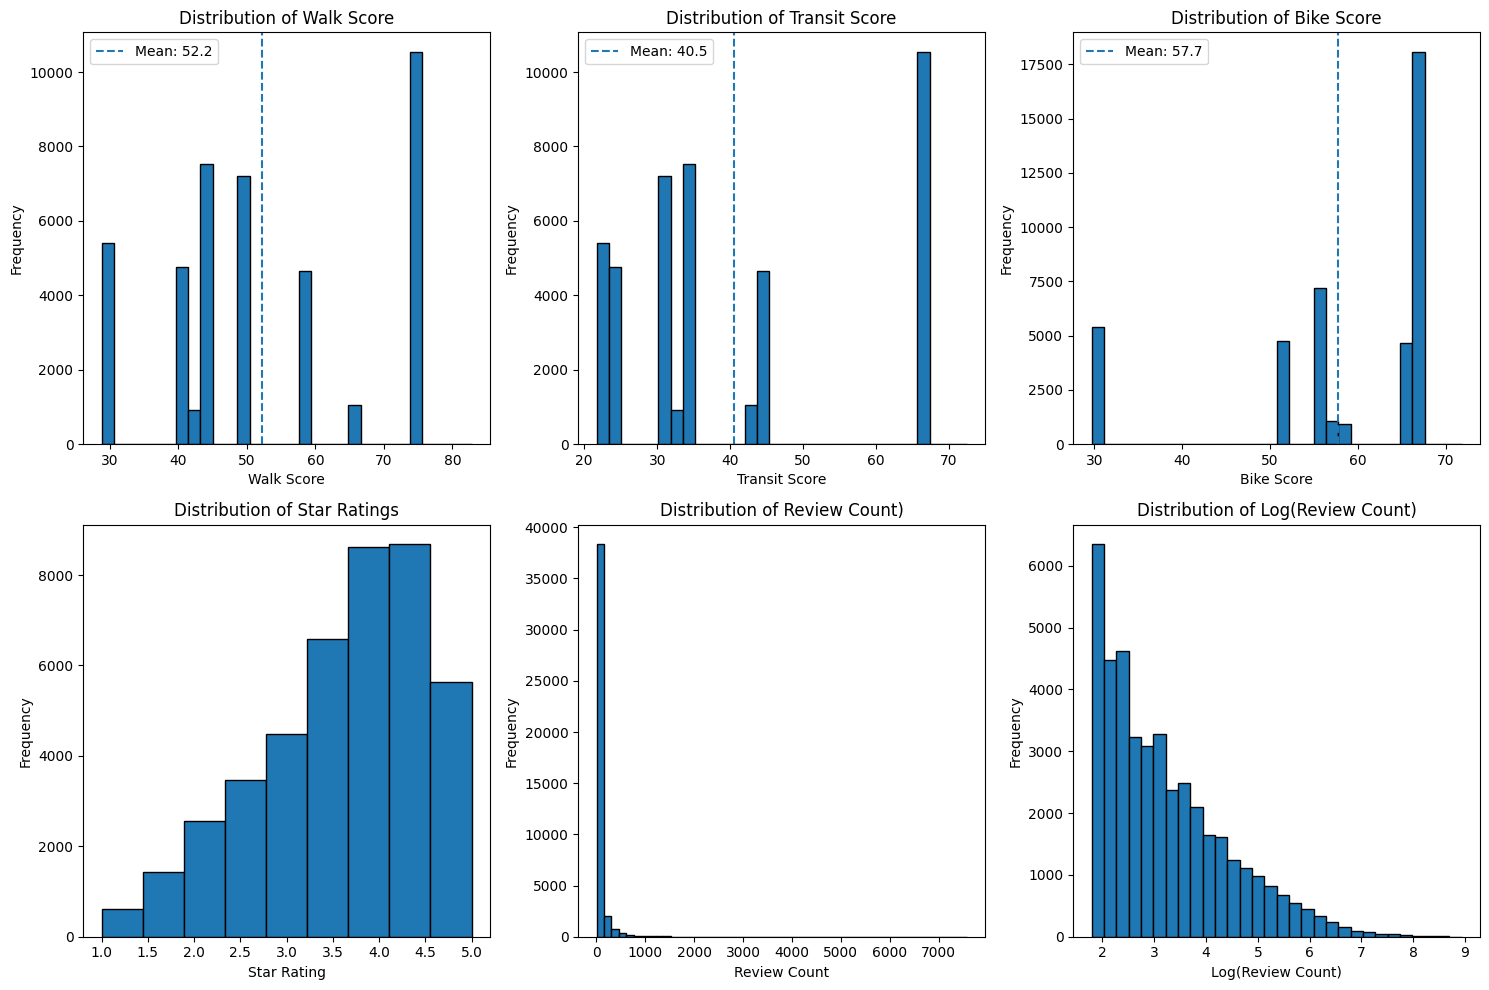

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Walk Score
axes[0, 0].hist(combined_final['Walk Score'], bins=30, edgecolor='black',)
axes[0, 0].set_xlabel('Walk Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Walk Score')
axes[0, 0].axvline(combined_final['Walk Score'].mean(), linestyle='--', label=f'Mean: {combined_final["Walk Score"].mean():.1f}')
axes[0, 0].legend()

# Transit Score
axes[0, 1].hist(combined_final['Transit Score'], bins=30, edgecolor='black',)
axes[0, 1].set_xlabel('Transit Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Transit Score')
axes[0, 1].axvline(combined_final['Transit Score'].mean(), linestyle='--', label=f'Mean: {combined_final["Transit Score"].mean():.1f}')
axes[0, 1].legend()

# Bike Score
axes[0, 2].hist(combined_final['Bike Score'], bins=30, edgecolor='black')
axes[0, 2].set_xlabel('Bike Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Bike Score')
axes[0, 2].axvline(combined_final['Bike Score'].mean(), linestyle='--', label=f'Mean: {combined_final["Bike Score"].mean():.1f}')
axes[0, 2].legend()

# Star Rating
axes[1, 0].hist(combined_final['stars'], bins=9, edgecolor='black',)
axes[1, 0].set_xlabel('Star Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Star Ratings')

# Review Count
axes[1, 1].hist(combined_final['review_count'], bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Review Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Review Count)')

# Review Count (after taking log)
axes[1, 2].hist(combined_final['log_review_count'], bins=30, edgecolor='black')
axes[1, 2].set_xlabel('Log(Review Count)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Log(Review Count)')

plt.tight_layout()
plt.show()

From this dashbaord here, we can see that the dataset generally contains businesses in areas that aren't very connected. The distribution of walk score tells us that there are roughly two groups: businesses in moderately walkable areas and businesses in highly walkable areas. The distribution of the Bike Score conveys the same information. In terms of Transit Score, however, the majority of businesses are in areas with low-to-moderate transit access, with a peak between 65-70.The distribution of star ratings is pretty left-skewed, which tells us that businesses are most likely to be rated on the higher end of things, which makes sense because people rarely tend to rate things below a 3 unless they had an exceptionally bad experience. The review count, by contrast, is severely right skewed, indicating that businesses rarely ever have over 200-300 reviews, so a rating for a particular business may not fully reflect what the population thinks of it. In order to further analyze the usefulness of our review counts, we take the log to carefully look at the distribution of our set. After this transformation, we see that the graph is much more normal which tells us that this could potentially be useful for regression analyses

## Bar Charts

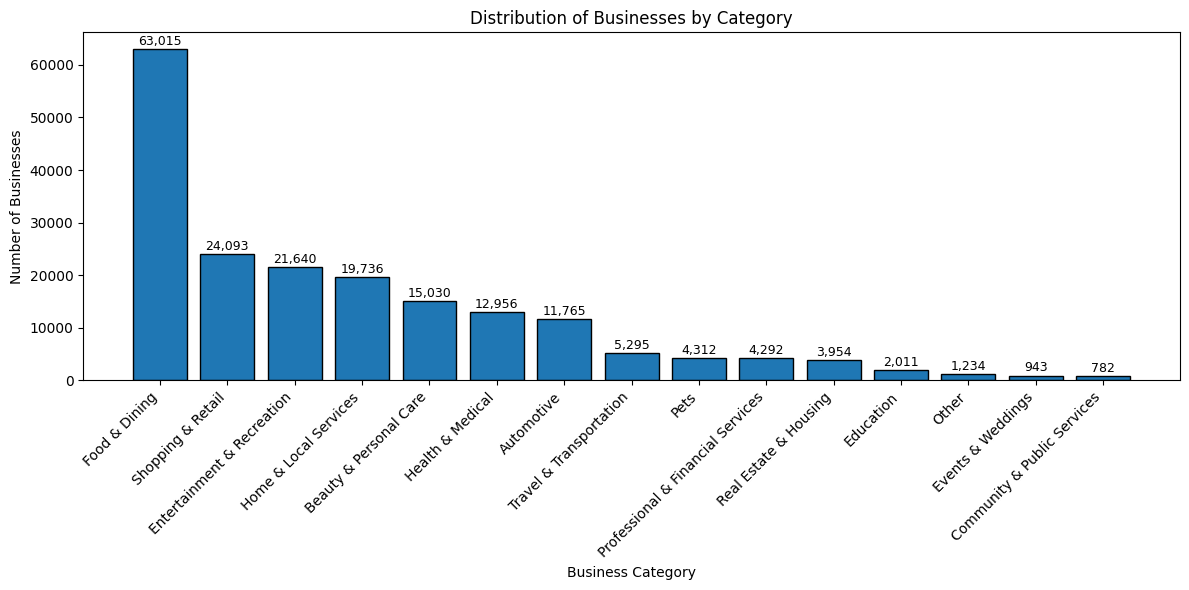

In [13]:
# Business count by category
category_counts = combined['major_category'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(category_counts)), category_counts.values, edgecolor='black')
plt.xticks(range(len(category_counts)), category_counts.index, rotation=45, ha='right')
plt.xlabel('Business Category')
plt.ylabel('Number of Businesses')
plt.title('Distribution of Businesses by Category')
for bar, val in zip(bars, category_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Box Plots

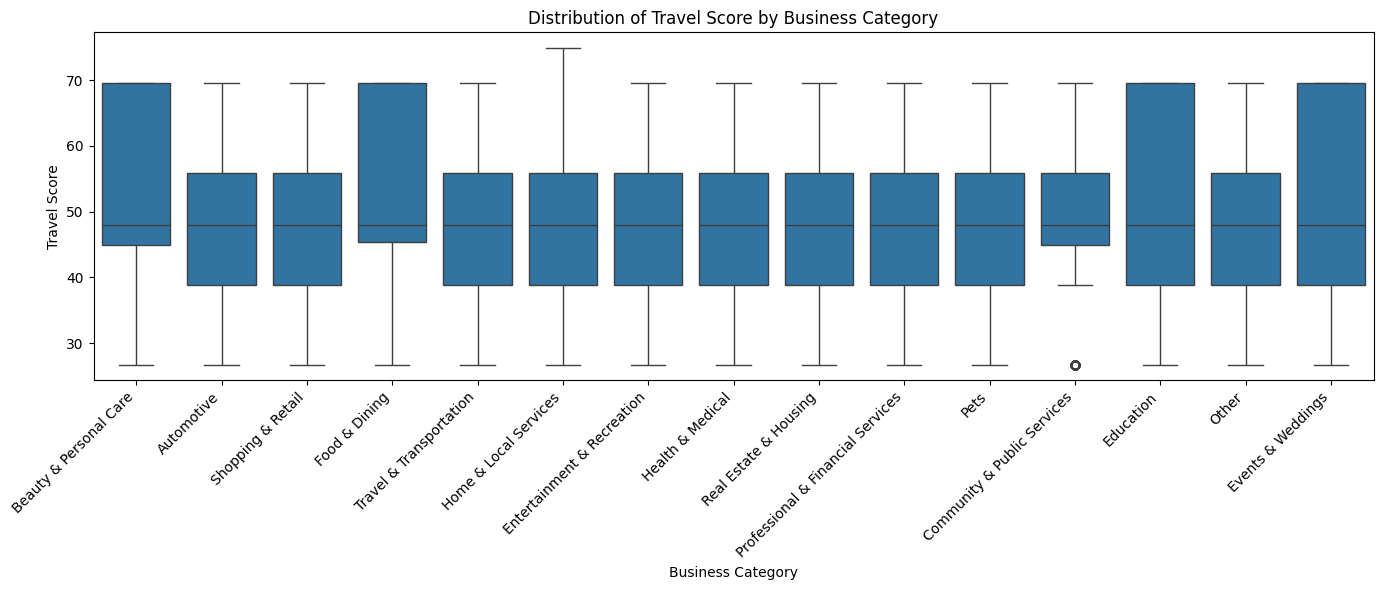

In [27]:
# Box plot: Travel Score by Business Category
plt.figure(figsize=(14, 6))
sns.boxplot(data=combined, x='major_category', y='Travel_Score')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Business Category')
plt.ylabel('Travel Score')
plt.title('Distribution of Travel Score by Business Category')
plt.tight_layout()
plt.show()

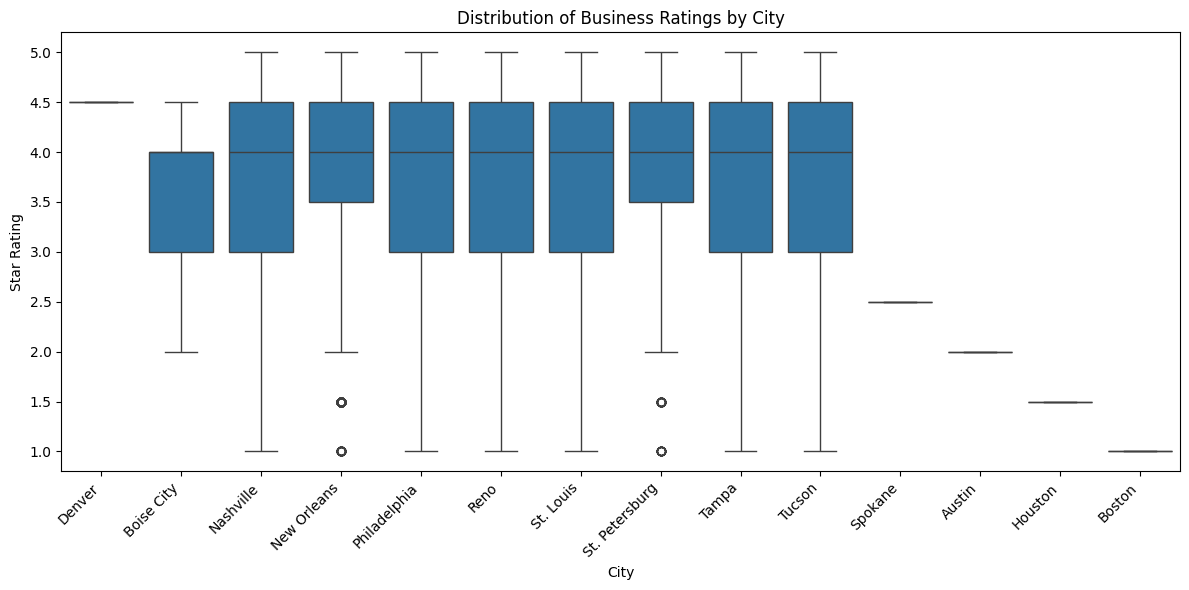

In [15]:
# Star Ratings by City
plt.figure(figsize=(12, 6))
city_order = combined_final.groupby('city')['stars'].median().sort_values(ascending=False).index
sns.boxplot(data=combined_final, x='city', y='stars', order=city_order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('City')
plt.ylabel('Star Rating')
plt.title('Distribution of Business Ratings by City')
plt.tight_layout()
plt.show()

The Travel Score by category boxplot shows different business types tend to cluster in areas with different travel scores. Entertainment and Food & Dining have higher median travel scores compared to Automotive and Home Services, which makes sense since restaurants and entertainment spots benefit from foot traffic and transit access. Auto shops and home services don't really need that though.
For the Star Ratings by city boxplot, medians are pretty consistent across cities, mostly around 3.5 to 4 stars. Spread varies though, some cities have tighter distributions and others are more scattered. Outliers show up in most cities which tells us business quality varies within each location regardless of what the urban characteristics look like.

## Scatter Plots

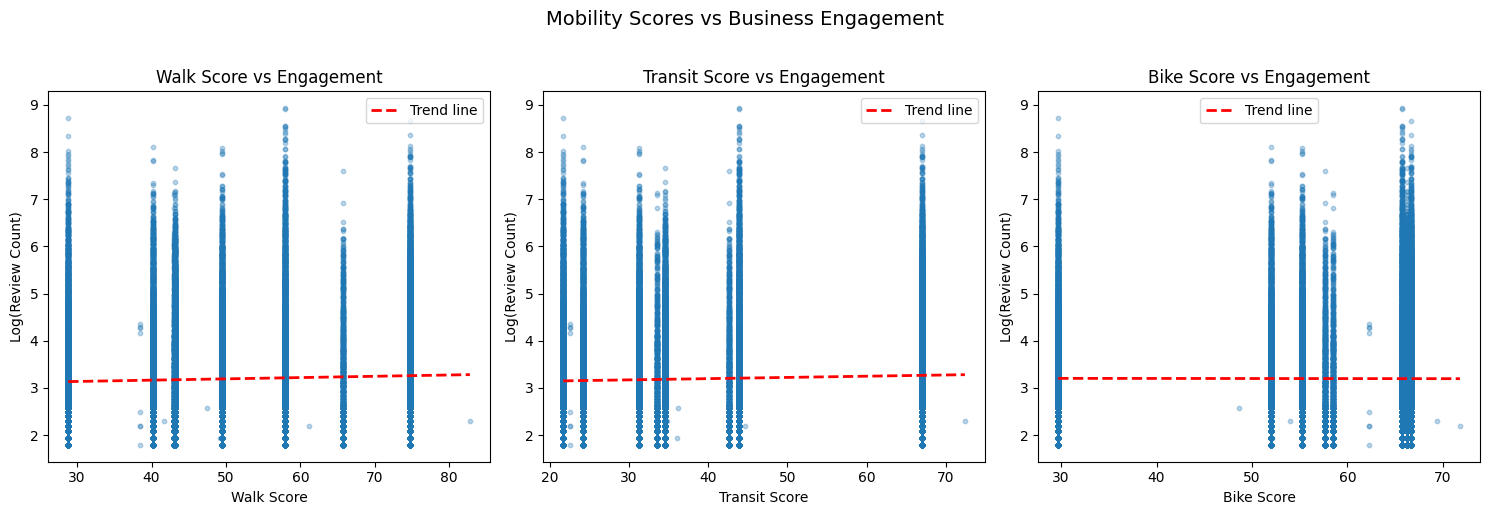

In [16]:
# Urban connectivity scores vs num reviews (Log)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, score in enumerate(['Walk Score', 'Transit Score', 'Bike Score']):
    axes[idx].scatter(combined_final[score], combined_final['log_review_count'], alpha=0.3, s=10)
    z = np.polyfit(combined_final[score], combined_final['log_review_count'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(combined_final[score].min(), combined_final[score].max(), 100)
    axes[idx].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
    axes[idx].set_xlabel(score)
    axes[idx].set_ylabel('Log(Review Count)')
    axes[idx].set_title(f'{score} vs Engagement')
    axes[idx].legend()

plt.suptitle('Mobility Scores vs Business Engagement', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The scatter plots show Walk Score, Transit Score, and Bike Score against review counts. There's a weak positive trend in each, you can see it in the slightly upward trend lines. That said, points are pretty scattered around those lines which tells us mobility scores alone aren't great predictors of how much engagement a business gets.
The variance is high though. Other factors like business quality, marketing, how long they've been open, probably matter more than location does.


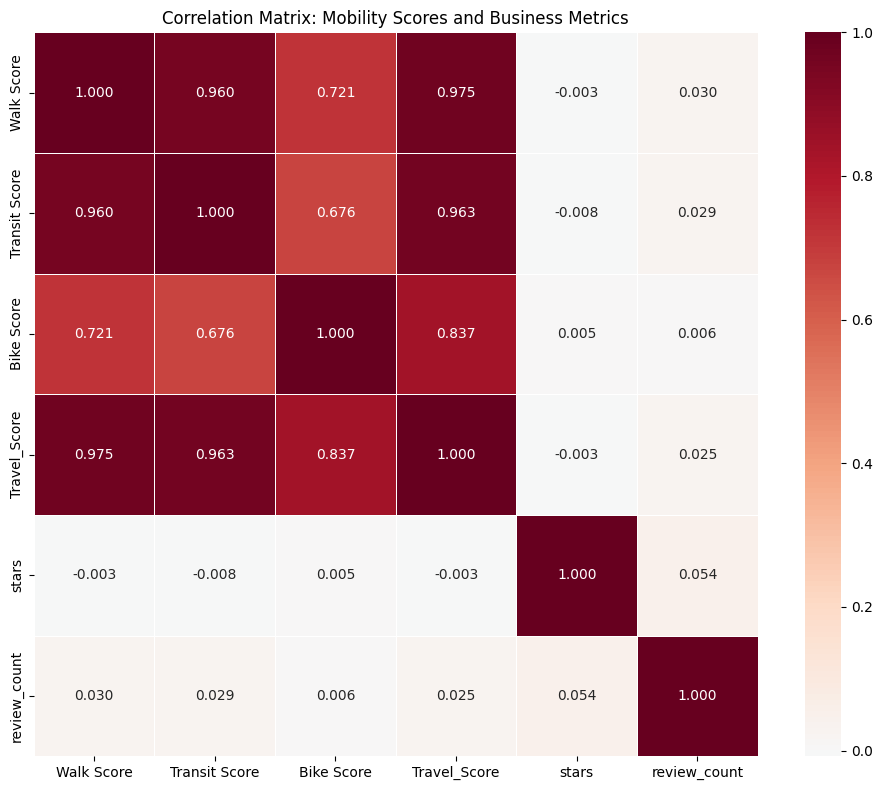

In [17]:
# Correlation heatmap
numeric_cols = ['Walk Score', 'Transit Score', 'Bike Score', 'Travel_Score', 'stars', 'review_count']
corr_matrix = combined_final[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True, linewidths=0.5, fmt='.3f')
plt.title('Correlation Matrix: Mobility Scores and Business Metrics')
plt.tight_layout()
plt.show()

The strong correlations among Walk, Transit, and Bike scores suggests these metrics are capturing the same underlying factors of urban layout. Cities that prioritize public transit tend to be built at a pedestrian scale, so the two scores moving together makes intuitive sense. Bike Score follows the same direction but with slightly weaker correlations (r = 0.721 with Walk, 0.676 with Transit), which is reasonable given that cycling infrastructure can exist independent of transit. The mobility scores have essentially no relationship with business performance, which we had previously verified in our regression analysis. 

---
# 3. Comparative Analysis

In this section, we compare different subsets of the data across cities and business categories

## City-Level Comparisons

In [18]:
# City-level statistics
city_stats = combined_final.groupby('city').agg({
    'business_id': 'count',
    'stars': 'mean',
    'review_count': 'mean',
    'Walk Score': 'first',
    'Transit Score': 'first',
    'Bike Score': 'first',
    'Travel_Score': 'first'
}).rename(columns={'business_id': 'num_businesses'})
city_stats = city_stats.sort_values('Travel_Score', ascending=False)

print("City-Level Comparison:")
print(city_stats.round(2))

City-Level Comparison:
                num_businesses  stars  review_count  Walk Score  \
city                                                              
Boston                       1   1.00          9.00        82.8   
Philadelphia             10540   3.65         68.34        74.8   
Denver                       1   4.50          8.00        61.2   
New Orleans               4648   3.85        112.96        58.0   
St. Louis                 1053   3.66         50.60        65.7   
Tucson                    7533   3.62         43.33        43.2   
Spokane                      1   2.50          6.00        49.2   
Tampa                     7217   3.60         50.87        49.5   
St. Petersburg             916   3.88         47.52        43.0   
Houston                      1   1.50         12.00        47.5   
Austin                       1   2.00          9.00        41.7   
Boise City                   8   3.56         39.50        38.5   
Reno                      4759   3.79  

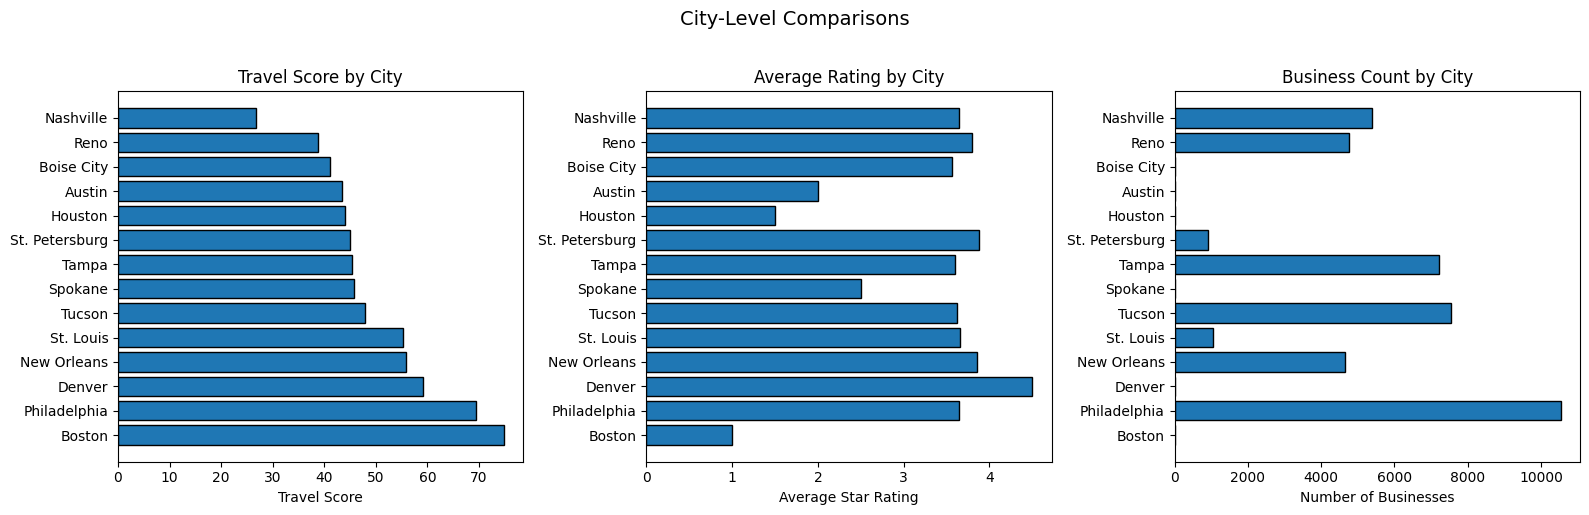

In [19]:
# City comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cities_sorted = city_stats.index.tolist()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cities_sorted)))

axes[0].barh(cities_sorted, city_stats['Travel_Score'], edgecolor='black')
axes[0].set_xlabel('Travel Score')
axes[0].set_title('Travel Score by City')

axes[1].barh(cities_sorted, city_stats['stars'], edgecolor='black')
axes[1].set_xlabel('Average Star Rating')
axes[1].set_title('Average Rating by City')

axes[2].barh(cities_sorted, city_stats['num_businesses'], edgecolor='black')
axes[2].set_xlabel('Number of Businesses')
axes[2].set_title('Business Count by City')

plt.suptitle('City-Level Comparisons', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# High-transit vs low-transit cities comparison
median_city_travel = city_stats['Travel_Score'].median()
high_transit_cities = city_stats[city_stats['Travel_Score'] >= median_city_travel].index.tolist()
low_transit_cities = city_stats[city_stats['Travel_Score'] < median_city_travel].index.tolist()

high_transit_data = combined_final[combined_final['city'].isin(high_transit_cities)]
low_transit_data = combined_final[combined_final['city'].isin(low_transit_cities)]

print("Comparison: High-Transit vs Low-Transit Cities")
print("="*60)
print(f"High-transit cities: {', '.join(high_transit_cities)}")
print(f"Low-transit cities: {', '.join(low_transit_cities)}")
print(f"\n{'Metric':<25} {'High-Transit':>15} {'Low-Transit':>15}")
print("-"*60)
print(f"{'Number of businesses':<25} {len(high_transit_data):>15,} {len(low_transit_data):>15,}")
print(f"{'Average rating':<25} {high_transit_data['stars'].mean():>15.2f} {low_transit_data['stars'].mean():>15.2f}")
print(f"{'Average review count':<25} {high_transit_data['review_count'].mean():>15.1f} {low_transit_data['review_count'].mean():>15.1f}")

Comparison: High-Transit vs Low-Transit Cities
High-transit cities: Boston, Philadelphia, Denver, New Orleans, St. Louis, Tucson, Spokane
Low-transit cities: Tampa, St. Petersburg, Houston, Austin, Boise City, Reno, Nashville

Metric                       High-Transit     Low-Transit
------------------------------------------------------------
Number of businesses               23,777          18,297
Average rating                       3.68            3.68
Average review count                 68.3            58.0


These graphs show that there is no definite relationship between Travel Score and either average star rating or business count, which also the regression findings. Boston and Philadelphia are at the top of the Travel Score ranking yet Boston appears with only a single business in the dataset, making its metrics unreliable as a data point. Philadelphia has the largest business count of any city in our data (~10,500), which suggests that higher urban density does correlate with a greater volume of commercial activity, even if it doesn't translate to higher ratings.
The Average Rating chart is notably flat across all cities, hovering in a narrow band around 3.5–4.0 stars independent of travel score. This lack of variation in ratings across cities with very different mobility profiles further supports the conclusion that walkability and transit access don't predict how well a business is received by customers and people rate their local businesses similarly whether they drove there or walked.


## Business Category Comparisons

In [21]:
# Category statistics
category_stats = combined.groupby('major_category').agg({
    'business_id': 'nunique',
    'stars': 'mean',
    'review_count': 'mean',
    'Travel_Score': 'mean'
}).rename(columns={'business_id': 'num_businesses'})
category_stats = category_stats.sort_values('num_businesses', ascending=False)

print("Business Category Comparison:")
print(category_stats.round(2))

Business Category Comparison:
                                   num_businesses  stars  review_count  \
major_category                                                           
Food & Dining                               17414   3.69        152.61   
Entertainment & Recreation                  10439   4.00         82.27   
Shopping & Retail                            9753   3.72         34.03   
Home & Local Services                        8618   3.64         21.16   
Automotive                                   5269   3.63         30.53   
Beauty & Personal Care                       5235   4.06         45.12   
Health & Medical                             4178   3.68         19.23   
Travel & Transportation                      2429   3.50         75.60   
Pets                                         2082   4.03         45.56   
Professional & Financial Services            2045   3.53         17.18   
Real Estate & Housing                        1817   3.07         17.18   
Other   

---
# 4. Multivariate Analysis

This section examines relationships among three or more variables using cross-tabulation, pivot tables, and multivariate visualizations.

## Cross-Tabulation: Mobility Scores x Category x Engagement

In [22]:
# Create quartiles
combined_final['Walk_Q'] = pd.qcut(combined_final['Walk Score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
combined_final['Transit_Q'] = pd.qcut(combined_final['Transit Score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
combined_final['Bike_Q'] = pd.qcut(combined_final['Bike Score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])

# Melt category columns
category_cols = [col for col in combined_final.columns if col.startswith('major_category_')]
multivar_df = combined_final.melt(
    id_vars=['business_id', 'Walk Score', 'Transit Score', 'Bike Score', 
            'Walk_Q', 'Transit_Q', 'Bike_Q', 'review_count', 'stars', 'log_review_count', 'city'],
    value_vars=category_cols,
    var_name='category',
    value_name='belongs'
)
multivar_df = multivar_df[multivar_df['belongs'] == 1].copy()
multivar_df['category'] = multivar_df['category'].str.replace('major_category_', '')

print(f"Multivariate dataset shape: {multivar_df.shape}")

Multivariate dataset shape: (72391, 13)


In [23]:
# Pivot table
pivot_walk = multivar_df.pivot_table(values='review_count', index='category', columns='Walk_Q', aggfunc='mean')

print("Cross-Tabulation: Average Review Count")
print("Rows: Business Category | Columns: Walk Score Quartile")
print("="*60)
print(pivot_walk.round(1))

Cross-Tabulation: Average Review Count
Rows: Business Category | Columns: Walk Score Quartile
Walk_Q                               Low  Med-Low  Med-High  High
category                                                         
Automotive                          30.8     27.2      32.8   NaN
Beauty & Personal Care              51.2     42.7      58.3   NaN
Community & Public Services         27.0     23.7      31.4   NaN
Education                           25.1     21.4      26.2   NaN
Entertainment & Recreation          95.6     77.3     110.7   NaN
Events & Weddings                   25.9     26.5      32.3   NaN
Food & Dining                      120.0     90.3     133.1   NaN
Health & Medical                    20.2     17.0      23.0   NaN
Home & Local Services               21.7     18.8      24.5   9.0
Other                               25.4     24.9      45.7   NaN
Pets                                61.4     53.2      71.7   NaN
Professional & Financial Services   18.7     17.

## Three-Way Pivot Table

In [24]:
# Three-way pivot with Walk, Transit, Category
top_cats = multivar_df['category'].value_counts().head(6).index.tolist()

three_way_pivot = multivar_df[multivar_df['category'].isin(top_cats)].pivot_table(
    values='review_count',
    index=['Walk_Q', 'Transit_Q'],
    columns='category',
    aggfunc='mean'
)

print("Three-Way Pivot Table: Walk x Transit Quartiles x Category")
print("Values = Average Review Count")
print("="*80)
print(three_way_pivot.round(1))

Three-Way Pivot Table: Walk x Transit Quartiles x Category
Values = Average Review Count
category            Automotive  Beauty & Personal Care  \
Walk_Q   Transit_Q                                       
Low      Low              31.2                    53.0   
         Med-Low          26.1                    35.2   
         Med-High          NaN                     NaN   
Med-Low  Low              31.2                    46.3   
         Med-Low          23.8                    38.7   
         Med-High          NaN                     6.0   
Med-High Med-High         32.8                    58.3   
High     High              NaN                     NaN   

category            Entertainment & Recreation  Food & Dining  \
Walk_Q   Transit_Q                                              
Low      Low                              98.5          123.3   
         Med-Low                          66.8           86.8   
         Med-High                          NaN            NaN   
Med-L

## Multivariate Regression by Category

In [25]:
# Multiple regression for each category
regression_results = []

for category in multivar_df['category'].unique():
    cat_data = multivar_df[multivar_df['category'] == category].copy()
    if len(cat_data) < 50:
        continue
    
    X = cat_data[['Walk Score', 'Transit Score', 'Bike Score']]
    y = cat_data['log_review_count']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    regression_results.append({
        'Category': category,
        'Walk Score (B)': model.coef_[0],
        'Transit Score (B)': model.coef_[1],
        'Bike Score (B)': model.coef_[2],
        'R-squared': model.score(X_scaled, y),
        'n': len(cat_data)
    })

reg_df = pd.DataFrame(regression_results).sort_values('R-squared', ascending=False)

print("Multivariate Regression: Mobility Scores -> Log(Review Count) by Category")
print("(Standardized coefficients - comparable across predictors)")
print("="*80)
print(reg_df.round(4).to_string(index=False))

Multivariate Regression: Mobility Scores -> Log(Review Count) by Category
(Standardized coefficients - comparable across predictors)
                         Category  Walk Score (B)  Transit Score (B)  Bike Score (B)  R-squared     n
                            Other         -0.0622             0.1722         -0.0329     0.0102   962
      Community & Public Services          0.1833            -0.0753         -0.0953     0.0080   611
                        Education          0.1685            -0.0765         -0.0480     0.0072   951
            Real Estate & Housing          0.0528             0.0114         -0.0095     0.0066  1817
                Events & Weddings         -0.1534             0.1649          0.0541     0.0059   588
Professional & Financial Services          0.0833            -0.0011         -0.0532     0.0054  2045
                 Health & Medical         -0.0829             0.1362         -0.0192     0.0051  4178
                             Pets          0.1514  

# Reflection

## Process and Challenges

The biggest challenge we encountered was the data merge. We started with 102 cities in the urban dataset but after merging on city and state with Yelp we only ended up with 14. It was frustrating to find out mid-analysis but we kept going since we could still answer our main questions. Looking back, trying to source a more complete Yelp-style dataset and making sure we were not using a subsetted dataset would have served us better in our analysis. 

The mobility scores (Walk, Transit, Bike) were also super correlated with each other which made regression tricky. We dealt with that by making a composite Travel Score, but that meant losing some of the detail between the three.

## Limitations

As for limitations, 14 cities isn't a lot to generalize from. And the Travel Score is city-level, so a downtown restaurant gets the same score as one in the suburbs which flattens a lot of the actual variation. Star ratings and review counts also aren't perfect measures of success since they depend on how long a business has been open and how review-heavy the category is.


## Areas for Further Research

For future work it'd be worth doing this at the neighborhood level instead of city level. Zip code or census tract walkability scores would probably show stronger relationships. Would also be interesting to see if cities that improved their transit over time saw changes in what kinds of businesses opened up.